In [53]:
import sys
import pathlib

# Upewnij sie, ze modul game_logic jest widoczny z poziomu notebooka
sys.path.insert(0, str(pathlib.Path(".").resolve()))

from game_logic import ExperimentConfig, run_experiments
from reporting import save_results

# ---------------------------------------------------------------
# Edytuj ponizsze wartosci, aby dostosowac eksperyment.
# Wszystkie parametry maja wartosci domyslne zgodne z poleceniem.
# ---------------------------------------------------------------
cfg = ExperimentConfig(
    variants=("minimax", "alpha_beta"),
    min_tokens=8,
    max_tokens=20,
    max_take=3,
    depths=(2, 3, 4, 5),
    games_per_depth=200,
    base_seed=20260419,
)

results = run_experiments(cfg)
save_results(results)

# Sprawozdanie: Dwuosobowe gry deterministyczne (Nim Misère)

## I. Wstep i metodologia eksperymentow
Analizowana gra to **Nim Misère** (wariant gry Nim, w ktorym przegrywa gracz zabierajacy ostatni zeton) dla $K=3$, gdzie liczba poczatkowych zetonow spelnia $N \in [8, 20]$.

Konfiguracja eksperymentow:
- glebokosci przeszukiwania: $d \in \{2, 3, 4, 5\}$,
- 200 partii dla kazdego wariantu i kazdej glebokosci,
- przeciwnik: gracz losowy.

Porownywane warianty:
- Minimax,
- Minimax z obcinaniem $\alpha$-$\beta$.

## II. Reprezentacja stanu gry
Stan gry reprezentuje klasa `GameState` i zawiera:
- `tokens_left` - liczbe zetonow pozostalych na stole,
- `current_player` - identyfikator gracza, ktory wykonuje ruch.

Gra ma pelna informacje i sume zerowa: zysk jednego gracza jest strata drugiego.

## III. Zastosowana funkcja oceny
Heurystyka opiera sie na wlasnosci gry Nim Misère:
pozycje, dla ktorych $N \equiv 1 \pmod{K+1}$, sa przegrywajace dla gracza bedacego na ruchu.

W implementacji:
- takie pozycje dostaja ocene strategiczna $-0.75$,
- pozostale pozycje dostaja $0.75$.

Dodatkowo uwzgledniono skladnik `progress bonus`, ktory rosnie wraz ze zmniejszaniem liczby zetonow i promuje szybsze domykanie partii.

Wymog losowania zrealizowano przez zebranie wszystkich ruchow o najlepszej ocenie, a nastepnie wybor jednego z nich funkcja `random.choice`.

In [54]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

results_path = Path('results.csv')
report_path = Path('results.md')

if not results_path.exists():
    raise FileNotFoundError('Brak pliku results.csv. Uruchom najpierw main.py.')

rows = []
with results_path.open('r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        row['depth'] = int(row['depth'])
        row['games'] = int(row['games'])
        row['win_rate_pct'] = float(row['win_rate_pct'])
        row['avg_time_ms'] = float(row['avg_time_ms'])
        row['avg_nodes'] = float(row['avg_nodes'])
        rows.append(row)

rows = [r for r in rows if r['depth'] in {2, 3, 4, 5}]
rows.sort(key=lambda r: (r['variant'], r['depth']))

if report_path.exists():
    display(Markdown('## IV. Wyniki (tabela)'))
    display(Markdown(report_path.read_text(encoding='utf-8')))
else:
    display(Markdown('## IV. Wyniki (tabela)'))
    display(Markdown('Plik results.md nie istnieje.'))

## IV. Wyniki (tabela)

| Wariant    | Glebokosc d | Partie | Wygrane [%] | Sredni czas ruchu [ms] | Srednia liczba wezlow |
|:-----------|------------:|-------:|------------:|-----------------------:|----------------------:|
| minimax    |           2 |    200 |        98.5 |                  0.009 |                 10.39 |
| minimax    |           3 |    200 |        99.0 |                  0.021 |                 29.21 |
| minimax    |           4 |    200 |        98.0 |                  0.051 |                 74.44 |
| minimax    |           5 |    200 |       100.0 |                  0.120 |                179.44 |
| alpha_beta |           2 |    200 |        98.5 |                  0.008 |                 10.39 |
| alpha_beta |           3 |    200 |        99.0 |                  0.020 |                 26.26 |
| alpha_beta |           4 |    200 |        98.0 |                  0.038 |                 52.31 |
| alpha_beta |           5 |    200 |       100.0 |                  0.074 |                 99.93 |


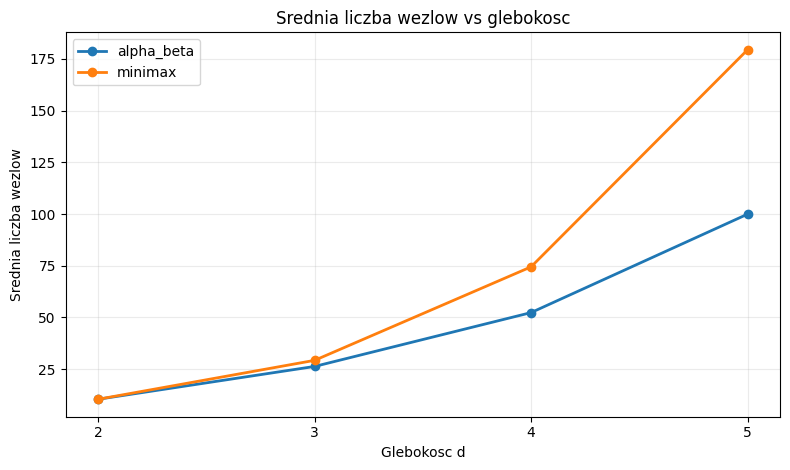

In [55]:
depths = sorted({r['depth'] for r in rows})
variants = sorted({r['variant'] for r in rows})

nodes_by_variant = {v: [] for v in variants}
for v in variants:
    indexed = {r['depth']: r['avg_nodes'] for r in rows if r['variant'] == v}
    nodes_by_variant[v] = [indexed[d] for d in depths]

plt.figure(figsize=(8, 4.8))
for v in variants:
    plt.plot(depths, nodes_by_variant[v], marker='o', linewidth=2, label=v)

plt.title('Srednia liczba wezlow vs glebokosc')
plt.xlabel('Glebokosc d')
plt.ylabel('Srednia liczba wezlow')
plt.xticks(depths)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

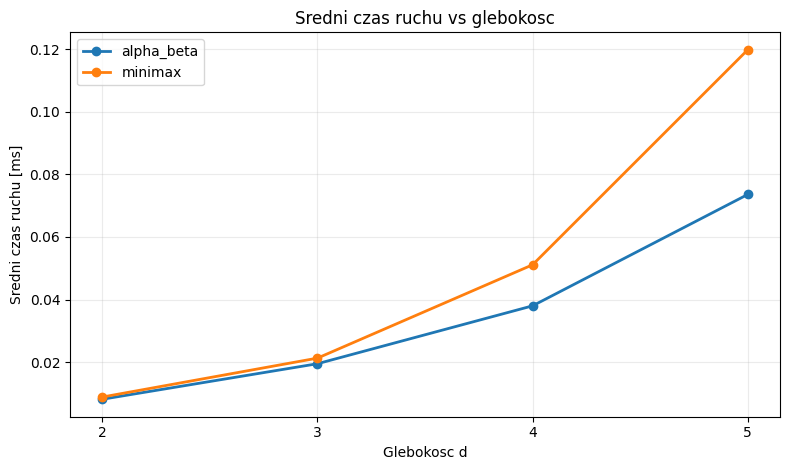

In [56]:
times_by_variant = {v: [] for v in variants}
for v in variants:
    indexed = {r['depth']: r['avg_time_ms'] for r in rows if r['variant'] == v}
    times_by_variant[v] = [indexed[d] for d in depths]

plt.figure(figsize=(8, 4.8))
for v in variants:
    plt.plot(depths, times_by_variant[v], marker='o', linewidth=2, label=v)

plt.title('Sredni czas ruchu vs glebokosc')
plt.xlabel('Glebokosc d')
plt.ylabel('Sredni czas ruchu [ms]')
plt.xticks(depths)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## V. Wnioski: wplyw obcinania $\alpha-\beta$
1. Jakosc decyzji
Skutecznosc obu wariantow jest bardzo zblizona (w tym 100% wygranych dla $d=5$), co potwierdza, ze obcinanie $\alpha-\beta$ nie zmienia decyzji strategicznych, a jedynie optymalizuje przeszukiwanie.

2. Male glebokosci
Dla $d=2$ oba algorytmy odwiedzaja srednio tyle samo wezlow (ok. 10.39), a czasy sa niemal identyczne. Drzewo jest zbyt male, aby obcinanie dawalo duzy efekt.

3. Wieksze glebokosci
Dla $d=5$ roznica jest wyrazna: Minimax odwiedza srednio ok. 179 wezlow (ok. 0.13 ms), a Alpha-Beta ok. 100 wezlow (ok. 0.07 ms). Oznacza to redukcje liczby analizowanych stanow i czasu ruchu o prawie polowe.

4. Podsumowanie
Wyniki eksperymentu sa zgodne z teoria: obcinanie $\alpha-\beta$ zachowuje jakosc decyzji i znaczaco poprawia wydajnosc wraz ze wzrostem glebokosci przeszukiwania.